In [5]:
!mkdir -p fonts
!wget -q https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf \
    -O fonts/NanumGothic.ttf

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont('fonts/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  

In [11]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(13)  # 숙제 번호 13을 시드로 (재현 가능성)
N = 150

genre = rng.choice(['뉴스', '소설', '대화', '학술'], size=N, p=[0.3, 0.3, 0.2, 0.2])
base = {'뉴스': 22, '소설': 18, '대화': 9, '학술': 28}  # 장르별 평균 어절 수
words = (np.array([base[g] for g in genre]) + rng.normal(0, 5, N)).clip(3, 60)
words = words.round().astype(int)
syllables = (words * 2.5 + rng.normal(0, 4, N)).clip(5, None).round().astype(int)
read_time = (syllables * 0.35 + rng.normal(0, 1.5, N)).clip(1, None).round(1)
difficulty = (words * 0.15 + rng.normal(0, 1.2, N)).clip(1, 10).round(1)

texts = pd.DataFrame({
    '장르': genre,
    '어절수': words,
    '음절수': syllables,
    '읽기시간': read_time,
    '난이도': difficulty,
})

# 연도별 신문/소설의 외래어 비율(%) (가상 데이터)
trends = pd.DataFrame({
    '연도': [1990, 1995, 2000, 2005, 2010, 2015, 2020],
    '뉴스': [5.1, 6.3, 8.0, 9.4, 11.2, 13.5, 15.1],
    '소설': [3.2, 3.5, 4.0, 4.6, 5.1, 5.8, 6.4],
})



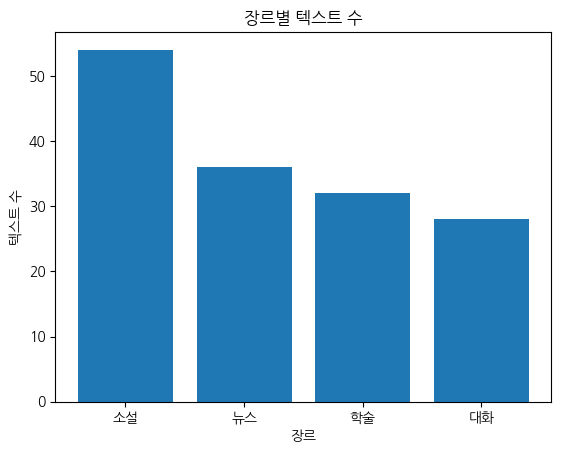

In [12]:
#1
ax = plt.subplot()
count = texts['장르'].value_counts()
ax.bar(count.index, count.values)
ax.set_title('장르별 텍스트 수') #코드 자동완성
ax.set_xlabel('장르') #코드 자동완성
ax.set_ylabel('텍스트 수') #코드 자동완성
plt.show() #코드 자동완성

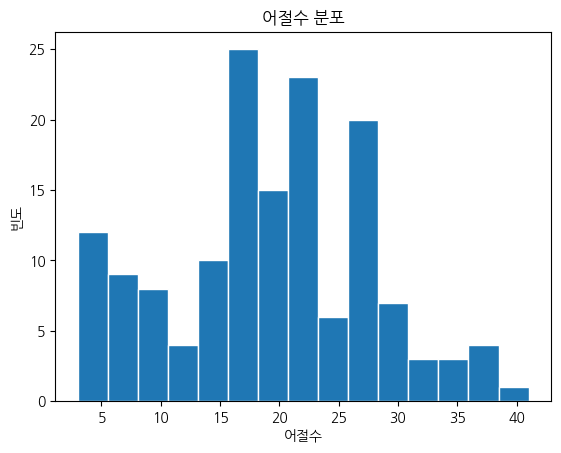

In [13]:
#B
fig, ax = plt.subplots()
ax.hist(texts['어절수'], bins=15, edgecolor='white')
ax.set_title('어절수 분포')
ax.set_xlabel('어절수')
ax.set_ylabel('빈도')
plt.show()
#3~6줄 코드 자동완성 사용


관찰: 어절수는 15~20 사이에 몰려있다

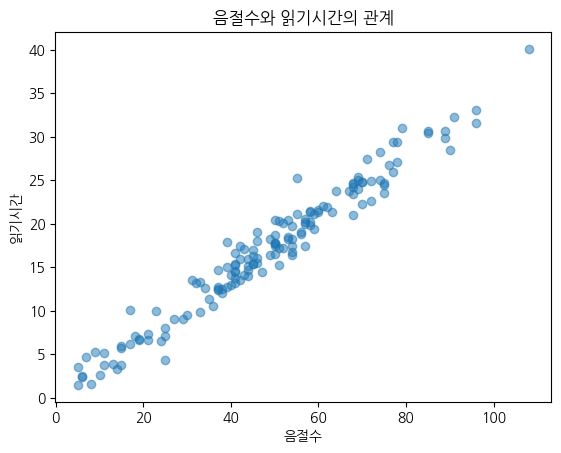

In [15]:
#c
fig, ax = plt.subplots()
ax.scatter(texts['음절수'], texts['읽기시간'], alpha=0.5)
ax.set_xlabel('음절수')
ax.set_ylabel('읽기시간')
ax.set_title('음절수와 읽기시간의 관계')
plt.show()
#3~6줄 코드 자동완성 사용

음절수와 읽기시간은 양의 상관관계가 있다

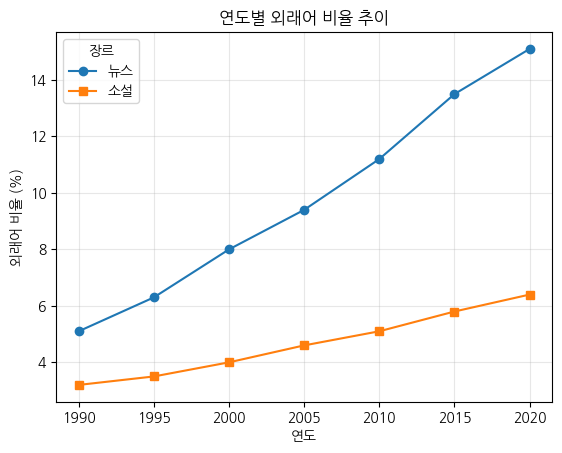

In [17]:
#2
fig, ax = plt.subplots() #자동완성
ax.plot(trends['연도'],trends['뉴스'],marker='o',label='뉴스') 
ax.plot(trends['연도'],trends['소설'],marker='s',label='소설')
ax.legend(title='장르')
ax.grid(True, alpha=0.3)
ax.set_title('연도별 외래어 비율 추이')
ax.set_xlabel('연도')
ax.set_ylabel('외래어 비율 (%)')
plt.show()
# 6~10줄 코드 자동완성 사용

뉴스의 외래어 비율이 더 가파르게 증가했다

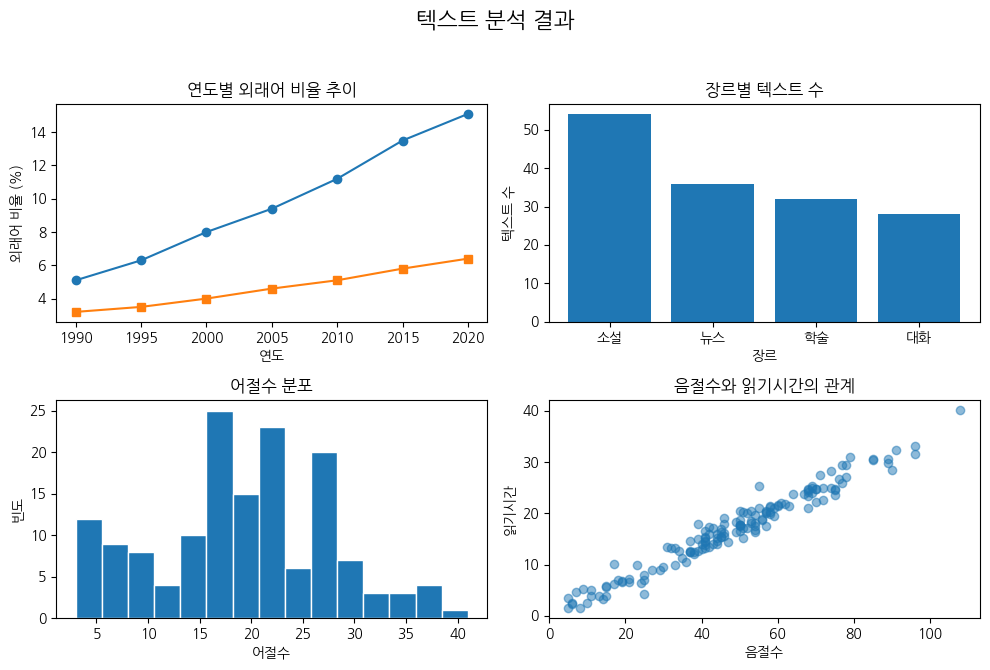

In [20]:
#b
fig, axes = plt.subplots(2,2, figsize= (10,7))
axes[0,0].plot(trends['연도'],trends['뉴스'],marker='o',label='뉴스') 
axes[0,0].plot(trends['연도'],trends['소설'],marker='s',label='소설')
axes[0,1].bar(count.index, count.values)
axes[1,0].hist(texts['어절수'], bins=15, edgecolor='white')
axes[1,1].scatter(texts['음절수'], texts['읽기시간'], alpha=0.5)
axes[0,0].set_title('연도별 외래어 비율 추이')
axes[0,0].set_xlabel('연도')
axes[0,0].set_ylabel('외래어 비율 (%)')
axes[0,1].set_title('장르별 텍스트 수') 
axes[0,1].set_xlabel('장르')
axes[0,1].set_ylabel('텍스트 수')
axes[1,0].set_title('어절수 분포')
axes[1,0].set_xlabel('어절수')
axes[1,0].set_ylabel('빈도')
axes[1,1].set_title('음절수와 읽기시간의 관계')
axes[1,1].set_xlabel('음절수')
axes[1,1].set_ylabel('읽기시간')

fig.suptitle('텍스트 분석 결과', fontsize=16) #코드 자동완성
fig.tight_layout(rect=[0, 0.03, 1, 0.95]) #코드 자동완성
fig.savefig('hw13_subplots.png',dpi=150,bbox_inches='tight') #코드 자동완성
plt.show()

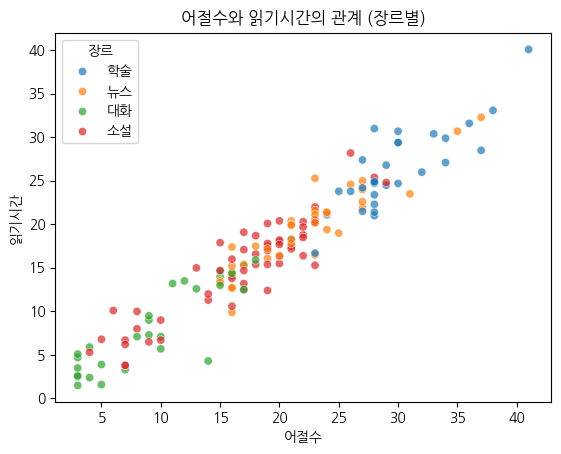

In [ ]:
#3
import seaborn as sns
fig, ax = plt.subplots()
sns.scatterplot(data=texts,x='어절수',y='읽기시간',hue='장르',alpha=0.7,ax=ax)
ax.set_title('어절수와 읽기시간의 관계 (장르별)')#자동완성
plt.show()

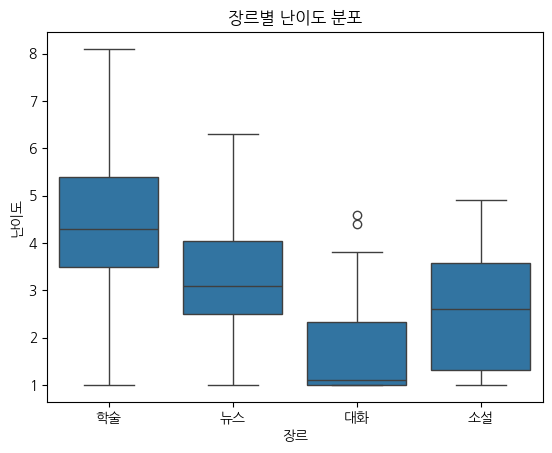

In [23]:
#b
fig, ax = plt.subplots()
sns.boxplot(data=texts,x='장르',y='난이도',ax=ax)
ax.set_title('장르별 난이도 분포') #코드 자동완성
plt.show()


학술 분야의 난이도가 가장 높고 난이도 분포가 가장 큰 장르역시 학술이다.

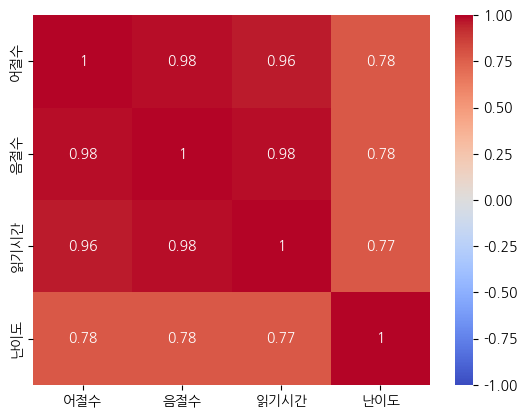

In [25]:
fig, ax = plt.subplots()
correlation = texts[['어절수','음절수','읽기시간','난이도']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm',vmin=-1,vmax=1, ax=ax)
plt.show()

음절수와 어절수는 서로의 상관계수가 0.98로 가장 높게 측정되었다.

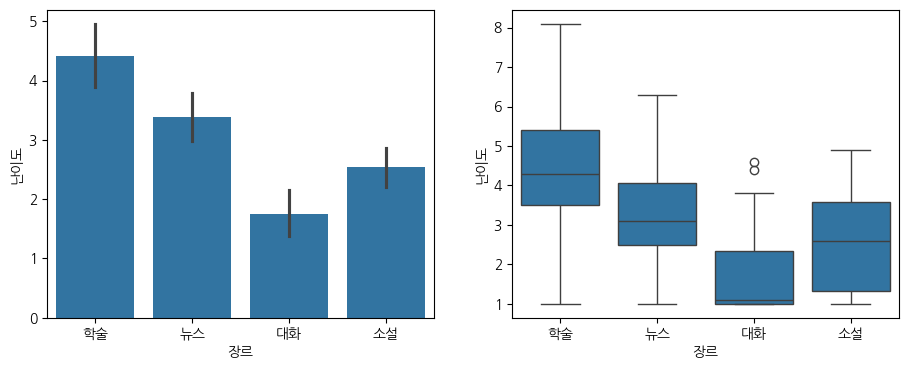

In [26]:
#4
fig,axes = plt.subplots(1,2,figsize = (11,4))
sns.barplot(data=texts,x='장르',y='난이도',ax=axes[0])
sns.boxplot(data=texts,x='장르',y='난이도',ax=axes[1])
plt.show()

오른쪽 그래프는 오른쪽 상자그림이 보여주는 분포와 이상치의 존재를 보여주지 못한다. 뉴스 장르와 소설 장르의 평균분포는 비슷하지만 소설이 더 분포가 고른 것을 볼 수 있다. 하지만 뉴스가 최고 난이도와 최저 난이도의 격차가 더 큰 것도 확인할 수 있다. 하지만 다이너마이트플롯은 그런 정보를 확인할 수 없다.

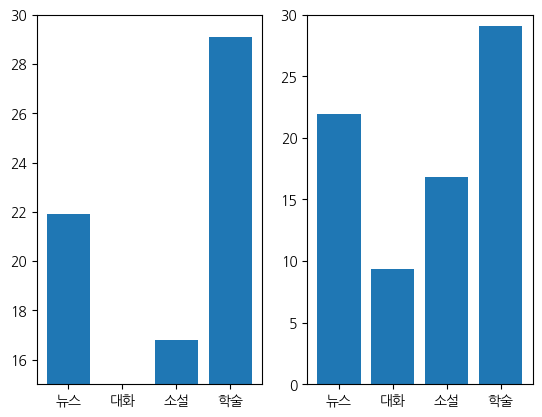

In [32]:
fig, axes = plt.subplots(1,2)
avg = texts.groupby('장르')['어절수'].mean()
axes[0].bar(avg.index, avg.values)
axes[0].set_ylim(15,30)
axes[1].bar(avg.index, avg.values)
axes[1].set_ylim(0,30)
plt.show()

막대그래프를 15부터 그릴경우 대화와 소설의 어절수가 학술에 비해 사실에 비해 더 적은 어절을 가진 것 처럼 표시된다. 막대그래프를 자를 경우 막대 길이의 비율이 차이나기 때문이다.